In [1]:
!pip install numpy pandas matplotlib scipy



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
!pip install numpy pandas matplotlib scipy


In [3]:
%matplotlib inline


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation



In [5]:
df = pd.read_csv("Test_Data.csv") # load the CSV file
df.head() # Displays the CSV files

,type,ms,ax,ay,az,a_mag,gx,gy,gz,w_mag,qw,qx,qy,qz,roll,pitch,yaw
0,IMU,2300,8.844,5.668,0.574,10.520,0.000,0.000,0.000,0.00,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1,IMU,2310,8.617,6.016,1.035,10.560,0.000,0.000,0.000,0.00,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,IMU,2322,8.617,6.016,1.035,10.560,0.000,0.000,0.000,0.00,0.536377,-0.006653,-0.759583,-0.36792,1.842994,-0.960958,-2.405683
3,IMU,2340,8.582,5.285,-0.039,10.079,0.000,0.000,0.000,0.00,0.536377,-0.006653,-0.759583,-0.36792,1.842994,-0.960958,-2.405683
4,IMU,2354,8.582,5.285,-0.039,10.079,0.437,-0.041,0.348,0.56,0.536377,-0.006653,-0.759583,-0.36792,1.842994,-0.960958,-2.405683


In [6]:
df.columns # shows the index of the file, this allows for calling data

Index(['type', 'ms', 'ax', 'ay', 'az', 'a_mag', 'gx', 'gy', 'gz', 'w_mag',
       'qw', 'qx', 'qy', 'qz', 'roll', 'pitch', 'yaw'],
      dtype='str')

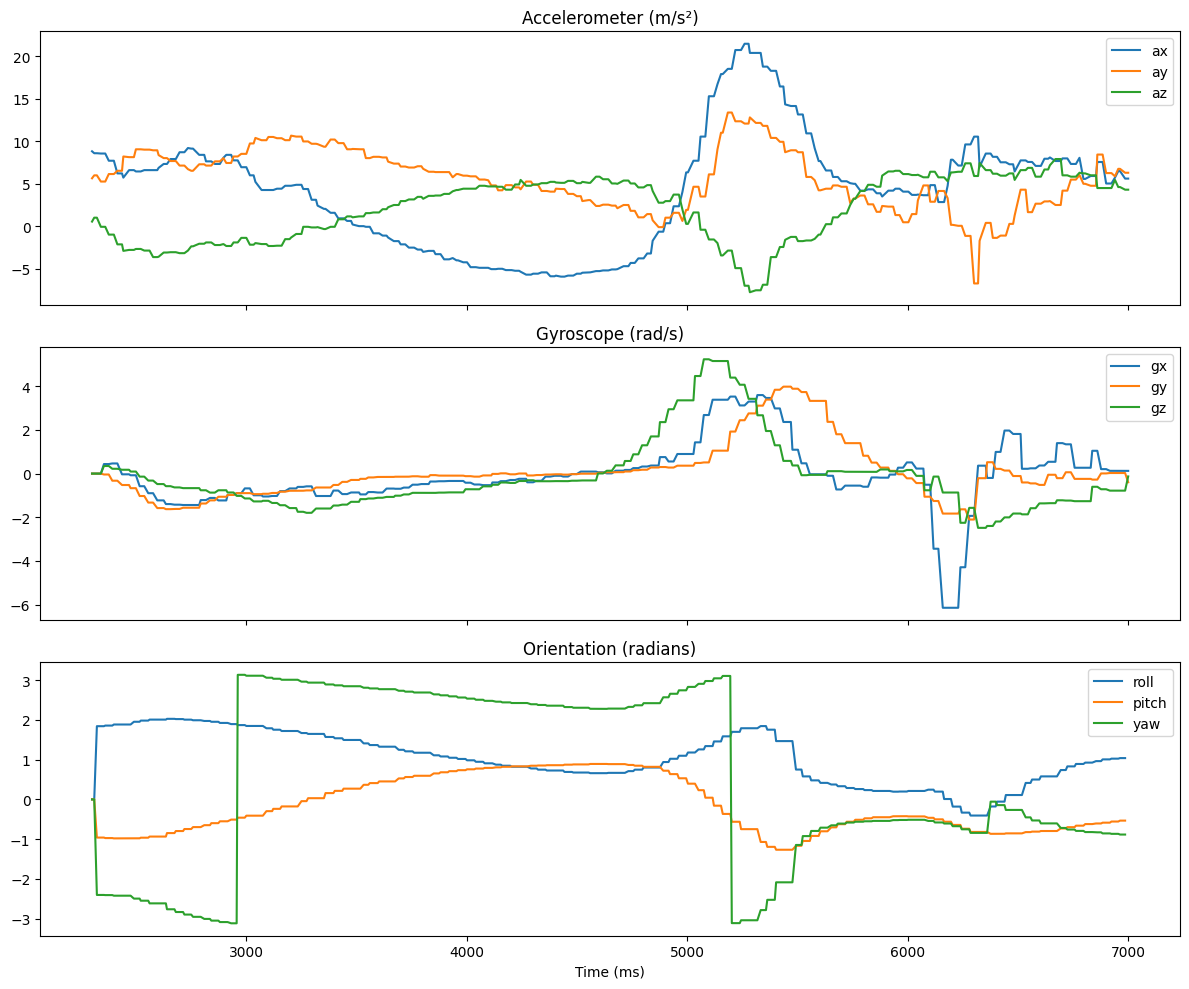

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Acceleration
axes[0].plot(df["ms"], df["ax"], label="ax")
axes[0].plot(df["ms"], df["ay"], label="ay")
axes[0].plot(df["ms"], df["az"], label="az")
axes[0].set_title("Accelerometer (m/s²)")
axes[0].legend()

# Gyroscope
axes[1].plot(df["ms"], df["gx"], label="gx")
axes[1].plot(df["ms"], df["gy"], label="gy")
axes[1].plot(df["ms"], df["gz"], label="gz")
axes[1].set_title("Gyroscope (rad/s)")
axes[1].legend()

# Orientation (Euler)
axes[2].plot(df["ms"], df["roll"], label="roll")
axes[2].plot(df["ms"], df["pitch"], label="pitch")
axes[2].plot(df["ms"], df["yaw"], label="yaw")
axes[2].set_title("Orientation (radians)")
axes[2].legend()

plt.xlabel("Time (ms)")
plt.tight_layout()
plt.show()


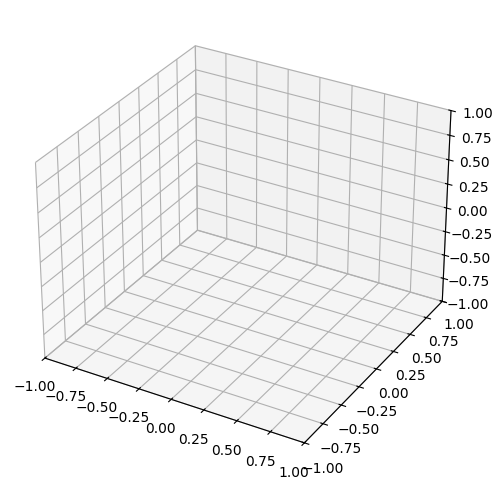

In [8]:
# Convert quaternion columns to scipy Rotation object
q = R.from_quat(df[["qx","qy","qz","qw"]].values)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])

line_x, = ax.plot([], [], [], 'r-', lw=3)
line_y, = ax.plot([], [], [], 'g-', lw=3)
line_z, = ax.plot([], [], [], 'b-', lw=3)

def update(i):
    rot = q[i].as_matrix()
    origin = np.array([0,0,0])

    line_x.set_data([origin[0], rot[0,0]], [origin[1], rot[1,0]])
    line_x.set_3d_properties([origin[2], rot[2,0]])

    line_y.set_data([origin[0], rot[0,1]], [origin[1], rot[1,1]])
    line_y.set_3d_properties([origin[2], rot[2,1]])

    line_z.set_data([origin[0], rot[0,2]], [origin[1], rot[1,2]])
    line_z.set_3d_properties([origin[2], rot[2,2]])

    return line_x, line_y, line_z

ani = FuncAnimation(fig, update, frames=len(df), interval=5)

plt.show()

# IMPORTANT: keep a reference so it doesn't get deleted
_ = ani


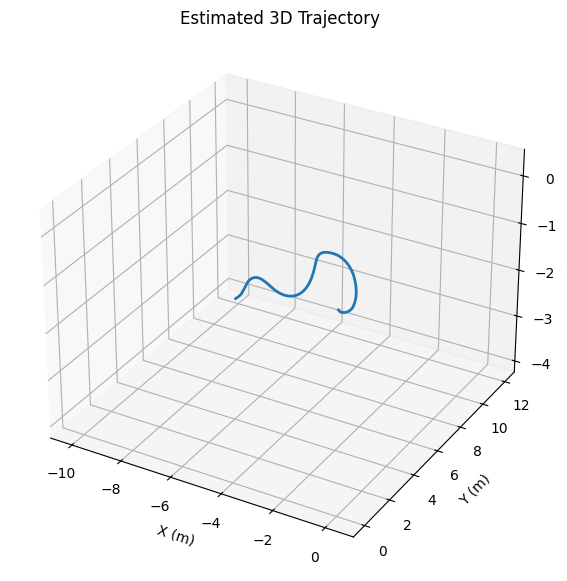

In [9]:
# Convert quaternion columns to scipy Rotation object
q = R.from_quat(df[["qx","qy","qz","qw"]].values)

# Gravity vector
g = np.array([0, 0, 9.81])

acc_world = []

# Rotate acceleration into world frame and remove gravity
for i in range(len(df)):
    rot = q[i].as_matrix()
    acc_body = df.loc[i, ["ax","ay","az"]].values
    acc_world.append(rot @ acc_body - g)

acc_world = np.array(acc_world)

# Convert ms → seconds for integration
dt = np.mean(np.diff(df["ms"])) / 1000.0

# Integrate acceleration → velocity → position
vel = np.cumsum(acc_world * dt, axis=0)
pos = np.cumsum(vel * dt, axis=0)

# Plot trajectory
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(pos[:,0], pos[:,1], pos[:,2], linewidth=2)
ax.set_title("Estimated 3D Trajectory")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")

plt.show()
